<table style="width:100%; border-bottom: 2px solid #ccc; margin-bottom: 20px;">
  <tr>
    <td style="vertical-align:middle;">
       <img src="../../resources/ADI-Logo-RGB-FullColor.png" alt="Company Logo" height="30">
    </td>
    <td style="text-align:right; vertical-align:middle;">
      <p style="margin: 0;">Phased Array Systems</p>
      <p style="font-size: 14px; margin: 0;">Iain Derrington – ADEF Group, ADI</p>
      <p style="font-size: 12px; color: #555;">Field Applications & Platform Engineer</p>
    </td>
  </tr>
</table>

# Adaptive Beamforming

## Overview

**Beamforming** is a signal processing technique used in antenna arrays to shape the spatial response of the system. By controlling the amplitude and phase of signals at each antenna element, we can steer the beam toward a desired direction and suppress signals from others.

In **adaptive beamforming**, the beam pattern is **adjusted dynamically** based on the incoming signal environment. This allows the system to track moving targets, reject interference, and improve signal-to-noise ratio (SNR) in real time.

## Objectives of Adaptive Beamforming

- **Maximize SNR**: Enhance reception in the desired direction.
- **Suppress Interference**: Place spatial nulls in the direction of interferers.
- **Adapt to Changing Environments**: Dynamically adjust to moving sources or changing conditions.


## MVDR Beamforming: A Practical Introduction

The several types of adaptive beamforming. 
- Least Mean Square
- Recursive Least Square
- Maximum Signal-to-Interference-plus-Noise Ratio
- Minimum Mean Squared Error
- Minimum Variance Distortionless Response (MVDR) / Capon

This notebook will focus on explaining an implementing MVDR using the CN0566 development platform.



## MVDR Beamformer: Concept and Formula

MVDR aims to **preserve the desired signal** while **minimizing total output power**, which suppresses noise and interference.

So lets jump right into the maths!
The weight vector is:

$
\large \mathbf{w}_{\text{MVDR}} = \frac{\mathbf{R}^{-1} \mathbf{a}(\theta_0)}{\mathbf{a}^H(\theta_0) \mathbf{R}^{-1} \mathbf{a}(\theta_0)}
$

Where:
- $\mathbf{a}(\theta_0)$ is the steering vector for the desired signal. (we understand this)
- $\mathbf{R}^{-1}$ acts like an interference-aware filter.  (This is new!!!)
- The denominator normalizes the response to keep the desired signal undistorted

$\mathbf{w}_{\text{MVDR}}$  is applied to the incoming signal and minimises interferes and focuses on the main signal. Lets try to understand what is going on. What is $\mathbf{R}^{-1}$ where does it come from? What does it do??

Its the inverse Covariance Matrix!  (Of course! :) )

## Covariance Matrix – Spatial Correlation of Signals

In adaptive beamforming, the **covariance matrix** describes how signals received by different antennas are correlated with one another. In otherwords, how similar is the signal on element 1 to element 2 etc etc.

This matrix captures the **spatial structure** of the environment — signal, interference, and noise — and is essential for algorithms like MVDR.

<details>
<summary>Mathematical Definition</summary>
    
### Definition

For an array signal vector $ \mathbf{x}(t) \in \mathbb{C}^N $, the **covariance matrix** is defined as:

$
\large \mathbf{R} = \mathbb{E}[\mathbf{x}(t)\mathbf{x}^H(t)]
$

In practice, we use a time-average approximation over $ T $ snapshots:

$
\large \mathbf{R} \approx \frac{1}{T} \sum_{t=1}^{T} \mathbf{x}(t)\mathbf{x}^H(t)
$
</details>



### Interpretation

- **Diagonal entries** → Power at each element
- **Off-diagonal entries** → Phase/amplitude relationships between elements (spatial coherence)
- If two antennas receive very similar signals, their correlation will be high


### Why It Matters

- MVDR uses $ \mathbf{R}^{-1} $ to shape the beam and suppress interference
- Eigenvalues of $ \mathbf{R} $ tell us how many strong signals or interferers exist. This is really interesting, but not covered here today.
- LMS adapts its weights based on the structure of $ \mathbf{R} $ (implicitly)

In [1]:
def steering_vector(theta_deg: float, N: int = 8, d: float = 0.5, wavelength: float = 1.0):
    """
    Generate the steering vector for a uniform linear array (ULA).

    Parameters
    ----------
    theta_deg : float
        Angle of arrival (or departure) in degrees.
    N : int, optional
        Number of antenna elements in the array. Default is 8.
    d : float, optional
        Element spacing in units of wavelength (e.g., 0.5 for λ/2). Default is 0.5.
    wavelength : float, optional
        Signal wavelength. Default is 1.0 (normalized units).

    Returns
    -------
    a : np.ndarray of complex128
        Steering vector of shape (N,), representing the phase shifts
        across the antenna array for a signal arriving at `theta_deg`.

    Notes
    -----
    The steering vector is defined as:
        a[n] = exp(-j * 2π * d * n * sin(theta) / λ)
    where n = 0, 1, ..., N-1.

    Assumes a broadside ULA lying along the x-axis.
    """
    theta_rad = np.deg2rad(theta_deg)
    k = 2 * np.pi / wavelength
    n = np.arange(N)
    return np.exp(-1j * k * d * n * np.sin(theta_rad))

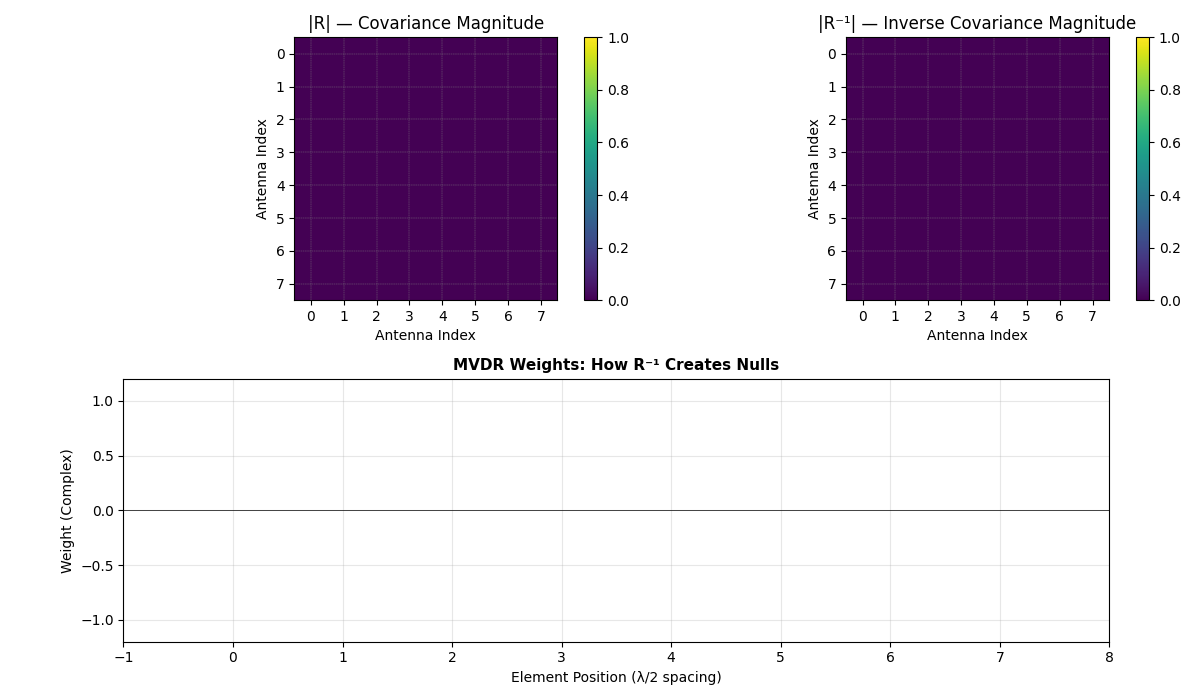

Output()

In [2]:
# Covariance Matrix Plot with MVDR Weight Visualization

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.gridspec import GridSpec

# Parameters
N = 8         # Number of antennas
T = 500       # Number of time samples

# --- Setup persistent figure with vertical layout ---
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1])

# Top row: Covariance matrix (magnitude)
ax_R = fig.add_subplot(gs[0, 0])
ax_invR = fig.add_subplot(gs[0, 1])

# Bottom row: Array weights visualization (spans both columns)
ax_weights = fig.add_subplot(gs[1, :])

# Setup covariance matrix images
im_R = ax_R.imshow(np.zeros((N, N)), cmap='viridis', vmin=0, vmax=1)
ax_R.set_title("|R| — Covariance Magnitude")
ax_R.set_xticks(np.arange(N))
ax_R.set_yticks(np.arange(N))
ax_R.set_xlabel("Antenna Index")
ax_R.set_ylabel("Antenna Index")
ax_R.grid(which='both', color='gray', linestyle='--', linewidth=0.3)
fig.colorbar(im_R, ax=ax_R, fraction=0.046)

im_invR = ax_invR.imshow(np.zeros((N, N)), cmap='viridis', vmin=0, vmax=1)
ax_invR.set_title("|R⁻¹| — Inverse Covariance Magnitude")
ax_invR.set_xticks(np.arange(N))
ax_invR.set_yticks(np.arange(N))
ax_invR.set_xlabel("Antenna Index")
ax_invR.set_ylabel("Antenna Index")
ax_invR.grid(which='both', color='gray', linestyle='--', linewidth=0.3)
fig.colorbar(im_invR, ax=ax_invR, fraction=0.046)

# Setup array weights visualization
ax_weights.set_xlim(-1, 8)
ax_weights.set_ylim(-1.2, 1.2)
ax_weights.set_aspect('equal')
ax_weights.set_xlabel('Element Position (λ/2 spacing)')
ax_weights.set_ylabel('Weight (Complex)')
ax_weights.set_title('MVDR Weights: How R⁻¹ Creates Nulls', fontweight='bold', fontsize=11)
ax_weights.grid(True, alpha=0.3)
ax_weights.axhline(0, color='k', linewidth=0.5)

# Annotations for signal directions (will update text later)
desired_text = ax_weights.text(0.02, 0.98, '', transform=ax_weights.transAxes, 
                               fontsize=9, verticalalignment='top',
                               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
interf_text = ax_weights.text(0.02, 0.85, '', transform=ax_weights.transAxes,
                              fontsize=9, verticalalignment='top',
                              bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()

  
# --- Update Function ---
def update(desired_angle=0, interference_angle=-20, interference_on=False):
    signal_power = 1.0

    # Generate desired signal
    a_desired = steering_vector(desired_angle, N)
    signal = np.sqrt(signal_power) * np.exp(1j * 2 * np.pi * 0.01 * np.arange(T))
    X_signal = np.outer(a_desired, signal)

    # NO NOISE - for clean visualization
    
    # Generate interference
    if interference_on:
        a_interf = steering_vector(interference_angle, N)
        interf = np.exp(1j * 2 * np.pi * 0.03 * np.arange(T))
        X_interf = np.outer(a_interf, interf)
    else:
        X_interf = np.zeros((N, T), dtype=np.complex128)

    # Combine signals (no noise)
    X = X_signal + X_interf
    
    # Compute covariance and inverse with diagonal loading for conditioning
    R = np.cov(X)
    # Add small diagonal loading (1% of trace) to make R⁻¹ well-conditioned
    loading = 0.01 * np.trace(R).real / N
    R_loaded = R + loading * np.eye(N)
    R_inv = np.linalg.inv(R_loaded)

    # --- Compute MVDR weights ---
    w_mvdr_numer = R_inv @ a_desired
    w_mvdr_denom = a_desired.conj().T @ R_inv @ a_desired
    w_mvdr = w_mvdr_numer / w_mvdr_denom

    # --- Update covariance matrix plots (magnitude only) ---
    mag_R = np.abs(R)
    mag_R_inv = np.abs(R_inv)
    
    # Normalize for better visualization
    im_R.set_data(mag_R / np.max(mag_R))
    im_invR.set_data(mag_R_inv / np.max(mag_R_inv))

    if interference_on:
        ax_R.set_title(f"|R| — Covariance (Signal: {desired_angle}°, Interf: {interference_angle}°)")
    else:
        ax_R.set_title(f"|R| — Covariance (Signal: {desired_angle}°, No Interference)")

    # --- Update weight visualization ---
    # Clear previous quiver and scatter plots
    for collection in ax_weights.collections[:]:
        collection.remove()
    
    # Plot MVDR weights as phasors (complex arrows) - SMALLER arrows now
    element_x = np.arange(N)
    element_y = np.zeros(N)
    
    # Normalize weights for visualization
    w_norm = w_mvdr / np.max(np.abs(w_mvdr))
    
    # Draw weight phasors (scale=7 makes them smaller)
    U = np.real(w_norm)  # Real part (x-component)
    V = np.imag(w_norm)  # Imag part (y-component)
    
    ax_weights.quiver(element_x, element_y, U, V, 
                     scale=7, width=0.006, headwidth=4, headlength=5,
                     color='blue', alpha=0.8, zorder=3, label='MVDR Weights')
    
    # Draw element markers on top
    ax_weights.scatter(element_x, element_y, s=100, c='black', marker='o', zorder=5, label='Array Elements')
    
    # Update legend (moved inside update to avoid warning)
    ax_weights.legend(loc='upper right', fontsize=8)
    
    # Compute and display array response to signals
    # Response from desired direction (constructive)
    response_desired = np.abs(np.vdot(w_mvdr, a_desired))
    
    # Response from interference direction (should be nulled)
    if interference_on:
        response_interf = np.abs(np.vdot(w_mvdr, a_interf))
        null_depth_dB = -20 * np.log10(response_interf / response_desired + 1e-10)
    else:
        null_depth_dB = 0
    
    # Update text annotations
    desired_text.set_text(f'✓ Desired ({desired_angle}°): Preserved\n  Response: {response_desired:.2f}')
    
    if interference_on:
        interf_text.set_text(f'✗ Interference ({interference_angle}°): Nulled\n  Null depth: {null_depth_dB:.1f} dB')
        interf_text.set_visible(True)
    else:
        interf_text.set_visible(False)

    fig.canvas.draw_idle()

# --- Widgets ---
desired_slider = widgets.IntSlider(min=-90, max=90, value=0, description="Desired θ")
interf_slider = widgets.IntSlider(min=-90, max=90, value=-20, description="Interf. θ")
interf_toggle = widgets.Checkbox(value=False, description="Interference ON")

ui = widgets.VBox([desired_slider, interf_slider, interf_toggle])
out = widgets.interactive_output(update, {
    'desired_angle': desired_slider,
    'interference_angle': interf_slider,
    'interference_on': interf_toggle
})

display(ui, out)

## Visualizing the Nulling Mechanism

This visualization shows **why** the MVDR weight pattern creates nulls by comparing what happens when signals arrive from different directions and interact with the weights.

**Left panel**: Signal from desired direction hits the weights → **Constructive interference** (phases add up)  
**Right panel**: Signal from interference direction hits the weights → **Destructive interference** (phases cancel, creating the null)

Output()

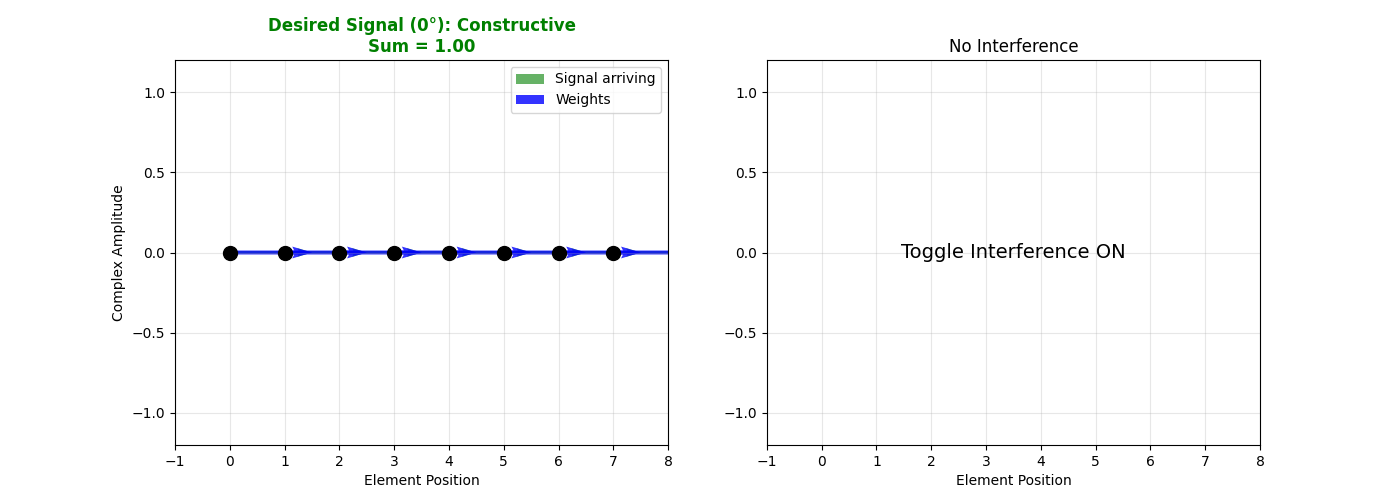

In [3]:
# Visualizing the Nulling Mechanism: Side-by-Side Comparison

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

N = 8
T = 500

fig, (ax_desired, ax_interf) = plt.subplots(1, 2, figsize=(14, 5))

def update_nulling_viz(desired_angle=0, interference_angle=-20, interference_on=False):
    # Generate signals
    a_desired = steering_vector(desired_angle, N)
    signal = np.exp(1j * 2 * np.pi * 0.01 * np.arange(T))
    X_signal = np.outer(a_desired, signal)

    if interference_on:
        a_interf = steering_vector(interference_angle, N)
        interf = np.exp(1j * 2 * np.pi * 0.03 * np.arange(T))
        X_interf = np.outer(a_interf, interf)
    else:
        X_interf = np.zeros((N, T), dtype=np.complex128)

    X = X_signal + X_interf
    R = np.cov(X)
    loading = 0.01 * np.trace(R).real / N
    R_inv = np.linalg.inv(R + loading * np.eye(N))
    w_mvdr = (R_inv @ a_desired) / (a_desired.conj().T @ R_inv @ a_desired)

    # Clear axes
    ax_desired.clear()
    ax_interf.clear()

    element_x = np.arange(N)

    # Left: Desired signal wavefront + weights
    ax_desired.scatter(element_x, np.zeros(N), s=100, c='black', marker='o', zorder=5)
    # Arriving wavefront from desired direction (green)
    U_sig = np.real(a_desired)
    V_sig = np.imag(a_desired)
    ax_desired.quiver(element_x, np.zeros(N), U_sig, V_sig,
                     scale=6, width=0.006, color='green', alpha=0.6, label='Signal arriving')
    # MVDR weights (blue)
    w_norm = w_mvdr / np.max(np.abs(w_mvdr))
    U_w = np.real(w_norm)
    V_w = np.imag(w_norm)
    ax_desired.quiver(element_x, np.zeros(N), U_w, V_w,
                     scale=6, width=0.008, color='blue', alpha=0.8, label='Weights')

    # Weighted response (element-wise product)
    weighted_response = w_mvdr * a_desired
    response_sum = np.sum(weighted_response)
    ax_desired.set_title(f'Desired Signal ({desired_angle}°): Constructive\nSum = {np.abs(response_sum):.2f}',
                        fontweight='bold', color='green')
    ax_desired.set_xlim(-1, 8)
    ax_desired.set_ylim(-1.2, 1.2)
    ax_desired.grid(True, alpha=0.3)
    ax_desired.legend(loc='upper right')
    ax_desired.set_xlabel('Element Position')
    ax_desired.set_ylabel('Complex Amplitude')

    # Right: Interference wavefront + weights
    if interference_on:
        ax_interf.scatter(element_x, np.zeros(N), s=100, c='black', marker='o', zorder=5)
        # Arriving wavefront from interference direction (red)
        U_int = np.real(a_interf)
        V_int = np.imag(a_interf)
        ax_interf.quiver(element_x, np.zeros(N), U_int, V_int,
                        scale=6, width=0.006, color='red', alpha=0.6, label='Interference arriving')
        # MVDR weights (blue)
        ax_interf.quiver(element_x, np.zeros(N), U_w, V_w,
                        scale=6, width=0.008, color='blue', alpha=0.8, label='Weights')

        # Weighted response
        weighted_interf = w_mvdr * a_interf
        interf_sum = np.sum(weighted_interf)
        null_depth = -20*np.log10(np.abs(interf_sum)/np.abs(response_sum) + 1e-10)
        ax_interf.set_title(f'Interference ({interference_angle}°): Destructive (NULL)\nSum ≈ 0, Depth = {null_depth:.1f} dB',
                           fontweight='bold', color='red')
        ax_interf.legend(loc='upper right')  # Only call legend when interference is ON
    else:
        ax_interf.text(0.5, 0.5, 'Toggle Interference ON', ha='center', va='center',
                      transform=ax_interf.transAxes, fontsize=14)
        ax_interf.set_title('No Interference')

    ax_interf.set_xlim(-1, 8)
    ax_interf.set_ylim(-1.2, 1.2)
    ax_interf.grid(True, alpha=0.3)
    ax_interf.set_xlabel('Element Position')

    fig.canvas.draw_idle()

# Widgets
desired_slider = widgets.IntSlider(min=-90, max=90, value=0, description="Desired θ")
interf_slider = widgets.IntSlider(min=-90, max=90, value=-20, description="Interf. θ")
interf_toggle = widgets.Checkbox(value=False, description="Interference ON")

ui = widgets.VBox([desired_slider, interf_slider, interf_toggle])
out = widgets.interactive_output(update_nulling_viz, {
    'desired_angle': desired_slider,
    'interference_angle': interf_slider,
    'interference_on': interf_toggle
})

display(ui, out)

### How R⁻¹ Creates Nulls: Understanding the MVDR Weight Vector

The **covariance matrix** $\mathbf{R}$ captures the **spatial correlation** between signals at different antennas. Its **inverse**, $\mathbf{R}^{-1}$, is used in the MVDR formula:

$
\mathbf{w}_{\text{MVDR}} = \frac{\mathbf{R}^{-1} \mathbf{a}(\theta_0)}{\mathbf{a}^H(\theta_0) \mathbf{R}^{-1} \mathbf{a}(\theta_0)}
$

But **how** does this create nulls at interference directions?

---

### The Nulling Mechanism: Weight Phasors (Right Panel)

The **right panel** shows the MVDR weight vector as **complex phasors** (arrows) at each array element:

- **Arrow direction** (angle) = phase of the weight
- **Arrow length** = magnitude of the weight
- **Array elements** (black dots) = physical antenna positions

#### What's Happening:

1. **R captures interference**: The covariance matrix encodes where interference is coming from through spatial correlation patterns

2. **R⁻¹ inverts the problem**: Computing $\mathbf{R}^{-1} \mathbf{a}(\theta_0)$ produces weights that:
   - Maintain **constructive interference** for signals from the desired direction (phases add up)
   - Create **destructive interference** for signals from the interference direction (phases cancel)

3. **The phase relationships matter**: The specific phase progression across elements is what creates the null

---

### Try This:

1. **Toggle "Interference ON/OFF"**:
   - **OFF**: Weights look like a simple steering vector (uniform phase progression)
   - **ON**: Weights become asymmetric — R⁻¹ has encoded the nulling information

2. **Move the interference angle slider**:
   - Watch how the **phasor pattern changes** to track the new interference direction
   - The **null depth (dB)** shows how well the interference is suppressed

3. **Observe the text boxes**:
   - Green box: Desired signal is preserved (response ~ 1.0)
   - Red box: Interference is nulled (null depth in dB)

---

### The Covariance Matrices (Left)

While the **heatmaps** of $\mathbf{R}$ and $\mathbf{R}^{-1}$ show complex patterns:

- **Diagonal entries** → Power at each element  
- **Off-diagonal entries** → Spatial correlation between element pairs

The **weight phasors** translate these patterns into **physical nulling**. The matrices are mathematically powerful but visually abstract — the phasors show the **mechanism**.

---

### Key Insight

**R captures WHERE the interference is** (through spatial correlation)  
↓  
**R⁻¹ inverts this to compute** weights that null it  
↓  
**The weight phasors show HOW** — through precise phase/amplitude relationships

### Next: Let's See MVDR Working in the Theoretical World

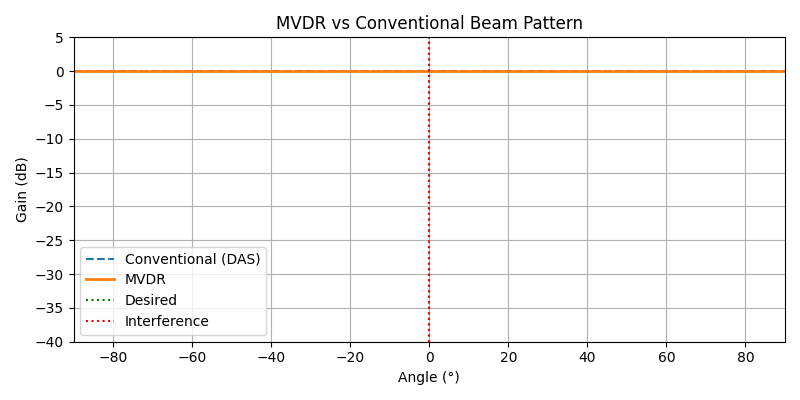

Output()

In [4]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display




# --- Create persistent plot ---
angles = np.linspace(-90, 90, 361)
fig, ax = plt.subplots(figsize=(8, 4))
line_das, = ax.plot(angles, np.zeros_like(angles), linestyle='--', label="Conventional (DAS)")
line_mvdr, = ax.plot(angles, np.zeros_like(angles), label="MVDR", linewidth=2)
vline_desired = ax.axvline(0, color='green', linestyle=':', label="Desired")
vline_interf = ax.axvline(0, color='red', linestyle=':', label="Interference")
ax.set_title("MVDR vs Conventional Beam Pattern")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Gain (dB)")
ax.set_ylim(-40, 5)
ax.set_xlim(-90, 90)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

def update_beam_pattern(desired_angle: int = 30, interference_angle: int = -20):
    """
    Update and plot the beam pattern for both MVDR and conventional (delay-and-sum) beamformers.

    Parameters
    ----------
    desired_angle : int, optional
        Angle (in degrees) of the desired signal direction. Default is 30°.
    interference_angle : int, optional
        Angle (in degrees) of a single interference source. Default is -20°.

    Returns
    -------
    None
        Updates the beam pattern lines in the existing matplotlib plot.

    Notes
    -----
    - The function simulates narrowband signals received by an 8-element uniform linear array.
    - Steering vectors are computed for each scan angle in the range [-90°, 90°].
    - MVDR weights are computed based on the sample covariance matrix of the received signal.
    - The beam pattern is plotted in dB scale over the scan angle range.
    """
    N = 8
    T = 500

    # Desired signal
    a_desired = steering_vector(desired_angle, N)
    signal = np.exp(1j * 2 * np.pi * 0.01 * np.arange(T))
    X_signal = np.outer(a_desired, signal)

    # Interference signal
    a_interf = steering_vector(interference_angle, N)
    interf = np.exp(1j * 2 * np.pi * 0.03 * np.arange(T))
    X_interf = np.outer(a_interf, interf)

    # Combine
    X = X_signal + X_interf
    R = np.cov(X)
    R_inv = np.linalg.pinv(R)

    # MVDR weights
    w_mvdr_numer = R_inv @ a_desired
    w_mvdr_denom = a_desired.conj().T @ R_inv @ a_desired
    w_mvdr = w_mvdr_numer / w_mvdr_denom

    # Conventional weights
    w_das = a_desired / N

    # Beam pattern
    mvdr_response = []
    das_response = []

    for theta in angles:
        a = steering_vector(theta, N)
        mvdr = np.abs( ( w_mvdr.conj().T @ a ).item())**2
        das = np.abs(np.vdot(w_das, a))**2
        mvdr_response.append(mvdr)
        das_response.append(das)

    mvdr_dB = 10 * np.log10(np.maximum(mvdr_response, 1e-6))
    das_dB = 10 * np.log10(np.maximum(das_response, 1e-6))

    # Update lines instead of creating new figure
    line_das.set_ydata(das_dB)
    line_mvdr.set_ydata(mvdr_dB)
    vline_desired.set_xdata([desired_angle])        
    vline_interf.set_xdata([interference_angle])   
    fig.canvas.draw_idle()

# --- Interactive controls ---
desired_slider = widgets.IntSlider(min=-90, max=90, value=30, step=1, description="Desired θ")
interf_slider = widgets.IntSlider(min=-90, max=90, value=-20, step=1, description="Interf. θ")

ui = widgets.HBox([desired_slider, interf_slider])
out = widgets.interactive_output(update_beam_pattern, {
    'desired_angle': desired_slider,
    'interference_angle': interf_slider
})

display(ui, out)


## Lets Run MVDR on the CN0566

There are some [severe] limitiations when running MVDR on the CN0566 as its a hybrid beam former with two channel 4:1 channels. Therefor we do not have access to signals at each element. We have two baseband signals, 1 from each of two ADAR1000. This will limit what we can achieve to a single null and single main lobe.

We will treat the CN00566 as just a two array BF.

Lets put together a script:

- HB100 Placed a boresite. This is our signal of interest.
- Generates the initial beam weights to steer the antenna to our desired location (0 Degrees)
- Collect the receive data
- Add a software generated interference signal. Make it optional
- Generate the adaptive beam steering weights and apply.
- Plot the before and after plots.

## Connect and Configure the CN0566

In [5]:
import sys
sys.path.insert(0, '../src')

%matplotlib widget

from time import sleep
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, update_display, Markdown
from phaser_functions import (calculate_plot, 
                                channel_calibration, 
                                gain_calibration, 
                                load_hb100_cal,
                                phase_calibration,
                                set_up_phaser,
                                doa_scan)
from phaser_init import init_phaser_sdr
import time

plt.style.use('ggplot')
np.set_printoptions(legacy='1.25', precision=2)

# Setup the phaser hardware
try:
    myPhaser = set_up_phaser()
except Exception as e:
    print(f"Error setting up phaser: {e}")
    exit(1)

Resource path: C:\ADI Repo\PhaserTes\resources
Attempting to connect to R_Pi via ip:192.168.1.10...
CN0566 Connected.
Attempting to connect to Pluto via ip:192.168.2.1...
PlutoSDR connected.

Initialise Pluto
Loaded filter: C:\ADI Repo\PhaserTes\beam-forming-tutorials\..\resources\LTE20_MHz.ftr
Converter Sample Rate = 30.0 Msps
SDR Tx frequency = 2.2 GHz (Not used)
SDR Rx frequency = 2.2 GHz (Pluto Rx LO)
Tx Gain = -6
Rx Gain =  6
Buffer size = 1024 bytes 

Apply channel calibration
Rx Chan 0 Cal = 0.0
Rx Chan 1 Cal = 0.26588858815922
file not found, loading default 10.5GHz
Found signal freq file f = 10500000000.0 Hz 
PLL fixed frequency = 3175000000/1e9 GHz
file not found, loading default (all gain at maximum)
file not found, loading default (no phase shift)
Gain Cal = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Phase Cal = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## How do we do make the CN0566 in to an all digital Beam Former:

We will turn down the gain of the outer elements such that we only have two inner elements providing signals, one for each ADC channel:

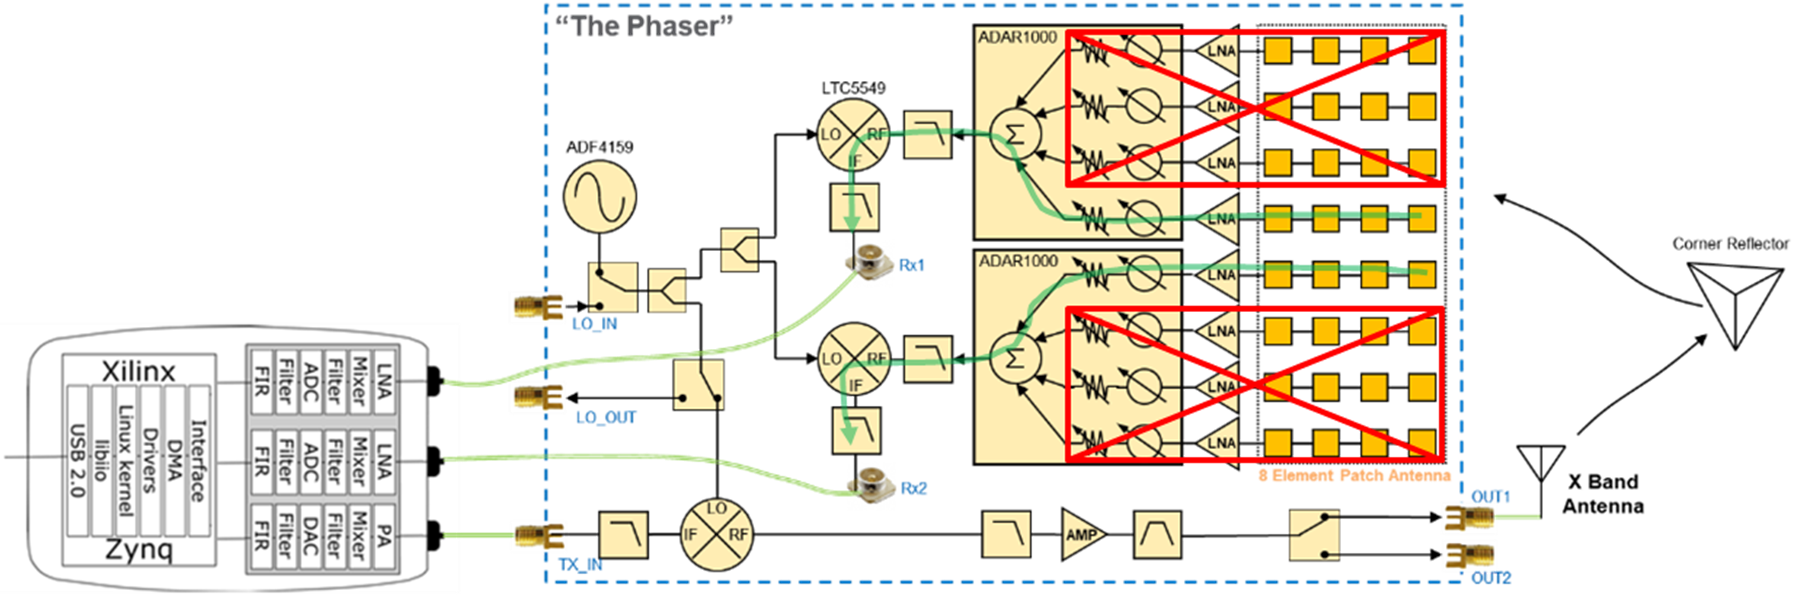

With only two elements now lets take a look at the DOA:

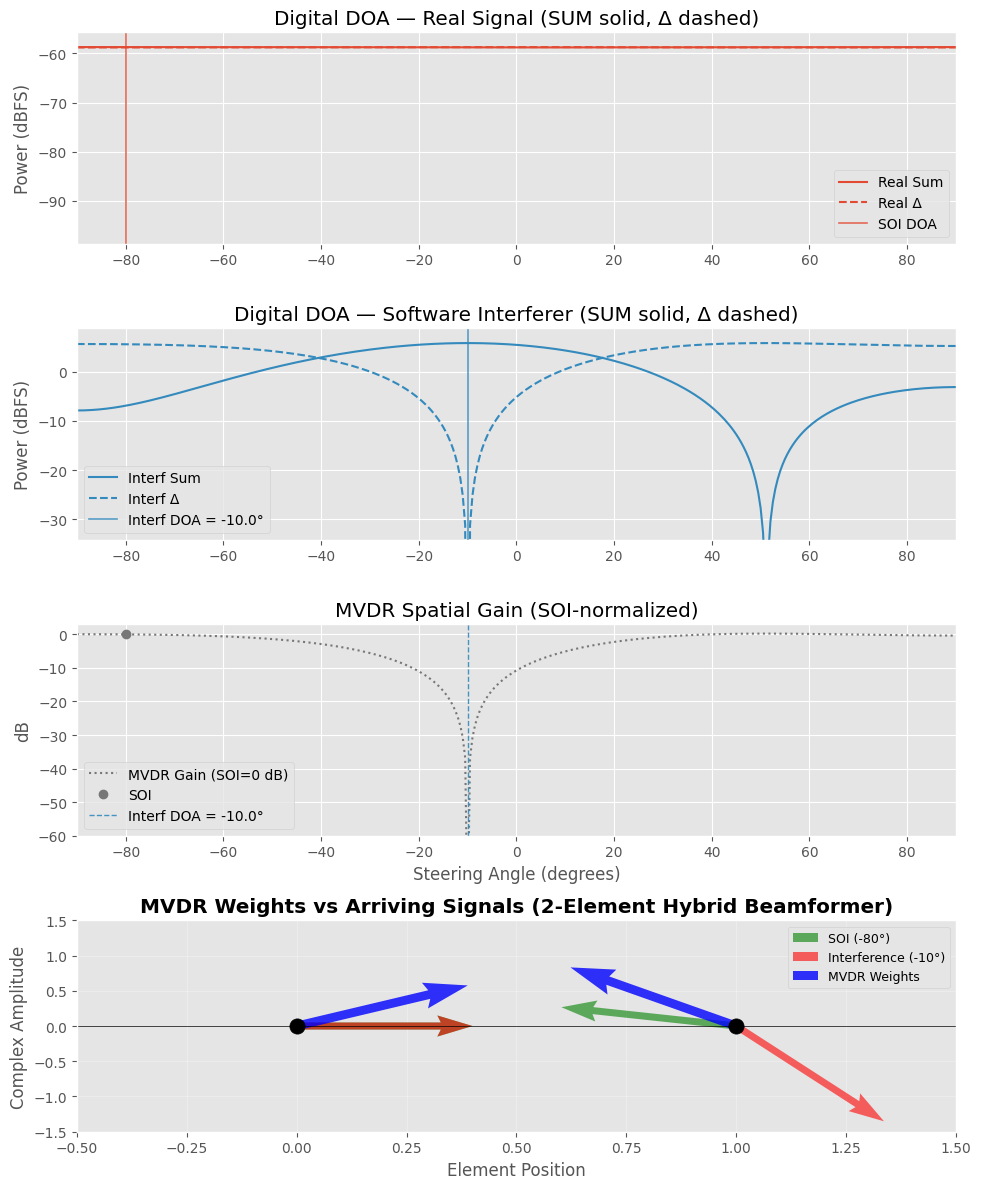

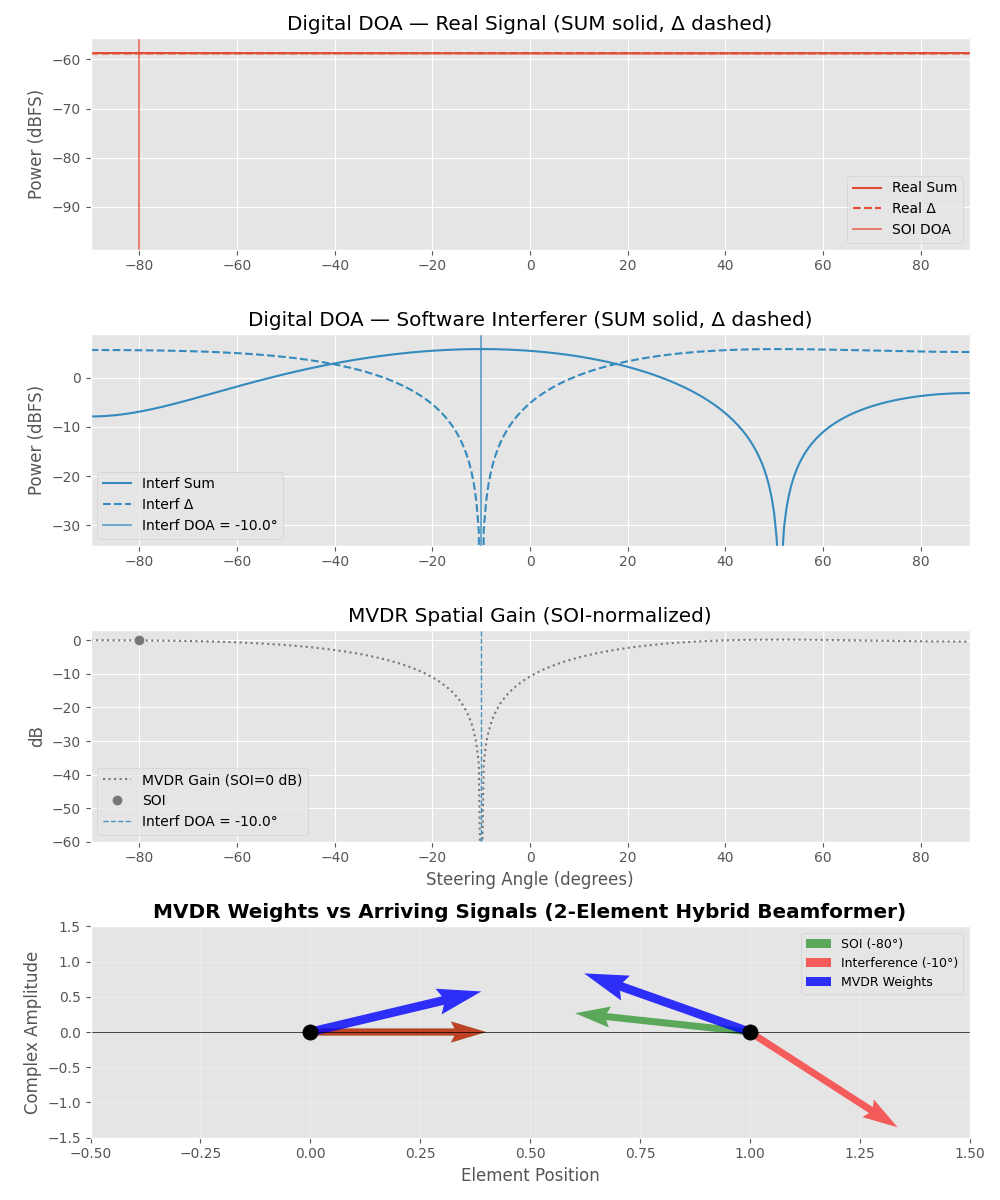

In [6]:
#Live Demo
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import time

def steering_vector_ULA(theta_deg: float, Nr: int, fc: float, d: float) -> np.ndarray:
    """
    """
    C = 3e8
    k = 2 * np.pi * fc * d / C
    return np.exp(1j * k * np.sin(np.deg2rad(theta_deg)) * np.arange(Nr)).reshape(-1, 1)

def acquire_frame(myPhaser):
    """Get one frame: two channels of length N as complex64 arrays."""
    rx = myPhaser.sdr.rx()                        # -> [list_len_N, list_len_N]
    x0 = np.asarray(rx[0], dtype=np.complex64)
    x1 = np.asarray(rx[1], dtype=np.complex64)
    return x0, x1

def collect_X(myPhaser, K: int = 5) -> np.ndarray:
    """Collect K frames (ADAR phases fixed), concatenate in time -> X shape (2, T)."""
    x0_list, x1_list = [], []
    for _ in range(K):
        x0, x1 = acquire_frame(myPhaser)
        x0_list.append(x0)
        x1_list.append(x1)
    x0 = np.concatenate(x0_list).astype(np.complex64)
    x1 = np.concatenate(x1_list).astype(np.complex64)
    X  = np.vstack([x0, x1])
    # Remove DC per channel
    X  = X - X.mean(axis=1, keepdims=True)
    return X

def estimate_tone_freq(x: np.ndarray, fs: float) -> float:
    """Simple FFT-bin peak frequency estimate (Hz)."""
    T = x.size
    X = np.fft.fft(x)
    k = int(np.argmax(np.abs(X)))
    k_signed = k - T if k > T//2 else k
    return k_signed * (fs / T)

def make_interferer(theta_i: float, f0: float, T: int, fs: float, fc: float, d: float, amp: float) -> np.ndarray:
    """Build a 2xT software interferer: complex tone at f0, from theta_i."""
    t = np.arange(T) / fs
    a_i = steering_vector_ULA(theta_i, 2, fc, d)           # (2,1)
    s   = amp * np.exp(1j * 2 * np.pi * f0 * t).reshape(1, -1)  # (1,T)
    return (a_i @ s).astype(np.complex64)                  # (2,T)

def digital_beam_scan_sum_delta(X: np.ndarray, angles_deg: np.ndarray, fc: float, d: float):
    """
    Compute SUM & Δ power over angles using unity-gain scaling.
    X: (2, T) raw channels. Returns linear powers.
    """
    S = np.diag([1, -1]).astype(np.complex64)
    P = len(angles_deg)
    sum_pow  = np.empty(P, dtype=float)
    diff_pow = np.empty(P, dtype=float)
    inv_norm = 1.0 / np.sqrt(2.0)  # ||a|| = sqrt(2) → unity scaling

    for i, th in enumerate(angles_deg):
        a = steering_vector_ULA(th, 2, fc, d)                 # (2,1)
        y_sum  = (a.conj().T       @ X).ravel() * inv_norm    # (T,)
        y_diff = ((S @ a).conj().T @ X).ravel() * inv_norm
        sum_pow[i]  = np.mean(np.abs(y_sum)**2)
        diff_pow[i] = np.mean(np.abs(y_diff)**2)
    return sum_pow, diff_pow

def to_dbfs(power_lin: np.ndarray) -> np.ndarray:
    """Convert linear power to dBFS using FS_RMS reference."""
    return 10*np.log10(np.maximum(power_lin / (FS_RMS**2), EPS))

def quick_two_channel_calibration(X: np.ndarray):
    """
    Estimate a simple diagonal calibration G = diag(g0, g1) to equalize the two channels.
    Uses sample covariance to match amplitudes and remove relative phase.
    Returns Ginv (apply as X_cal = Ginv @ X) and G for reference.
    """
    R = (X @ X.conj().T) / X.shape[1]   # (2,2)
    g0 = 1.0 + 0j
    ph = -np.angle(R[1, 0])             # remove relative phase
    mag = np.sqrt((np.abs(R[0, 0]) + EPS) / (np.abs(R[1, 1]) + EPS))
    G  = np.diag([g0, mag * np.exp(1j * ph)]).astype(np.complex64)
    Ginv = np.diag([1/g0, 1/(mag * np.exp(1j * ph))]).astype(np.complex64)
    return Ginv, G

plt.ion()  # interactive draws

# =========================
# Configuration
# =========================
K            = 5                                 # frames averaged per update
angles_deg   = np.linspace(-90, 90, 361)
fc           = myPhaser.signalFreq               # RF center (e.g., ~10 GHz)
d            = myPhaser.element_spacing          # element spacing (m)
                                                 # software interferer DOA (deg)
theta_i      = [-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50]                 
intf_amp     = 2000.0                            # interferer amplitude (ADC-code units)
add_interfer = True                              # toggle software interferer
update_dt    = 0.01                              # seconds between updates
load_frac    = 3e-4                              # diagonal loading fraction for MVDR
EPS          = 1e-15

# ADC full-scale for dBFS
NBITS   = 12
FS_PEAK = (2**(NBITS-1) - 1)                     # 2047 for 12-bit signed
FS_RMS  = FS_PEAK / np.sqrt(2)                   # full-scale sine RMS (ADC codes)

# =========================
# Figure & static artists (only data updated in loop)
# =========================
fig, ax = plt.subplots(4, 1, figsize=(10, 12), sharex=False)

# 1) Top subplot: DOA (SUM/Δ) for REAL signal only
real_sum_line,  = ax[0].plot([], [], color='C0', label="Real Sum")
real_diff_line, = ax[0].plot([], [], color='C0', linestyle='--', label="Real Δ")
sig_v = ax[0].axvline(0, color='C0', linestyle='-', linewidth=1.2, alpha=0.8, label="SOI DOA")
ax[0].set_title("Digital DOA — Real Signal (SUM solid, Δ dashed)")
ax[0].set_ylabel("Power (dBFS)")
ax[0].grid(True)
ax[0].legend(loc="best")

# 2) Second subplot: DOA (SUM/Δ) for SOFTWARE INTERFERER only
intf_sum_line,  = ax[1].plot([], [], color='C1', label="Interf Sum")
intf_diff_line, = ax[1].plot([], [], color='C1', linestyle='--', label="Interf Δ")
int_v = ax[1].axvline(theta_i[0], color='C1', linestyle='-', linewidth=1.2, alpha=0.8,
                      label=f"Interf DOA = {theta_i[0]:.1f}°")
ax[1].set_title("Digital DOA — Software Interferer (SUM solid, Δ dashed)")
ax[1].set_ylabel("Power (dBFS)")
ax[1].grid(True)
ax[1].legend(loc="best")

# 3) Third subplot: MVDR beampattern (SOI-normalized)
mvdr_line,  = ax[2].plot([], [], ':',  color='C3', label="MVDR Gain (SOI=0 dB)")
soi_marker, = ax[2].plot([], [], 'o',  color='C3', label="SOI")
int_v_mvdr  = ax[2].axvline(theta_i[0], color='C1', linestyle='--', linewidth=1.0, alpha=0.9,
                            label=f"Interf DOA = {theta_i[0]:.1f}°")
ax[2].set_title("MVDR Spatial Gain (SOI-normalized)")
ax[2].set_xlabel("Steering Angle (degrees)")
ax[2].set_ylabel("dB")
ax[2].grid(True)
ax[2].legend(loc="best")

# 4) Fourth subplot: Weight phasors visualization (2-element array)
ax[3].set_xlim(-0.5, 1.5)
ax[3].set_ylim(-1.5, 1.5)
ax[3].set_xlabel('Element Position')
ax[3].set_ylabel('Complex Amplitude')
ax[3].set_title('MVDR Weights vs Arriving Signals (2-Element Hybrid Beamformer)', fontweight='bold')
ax[3].grid(True, alpha=0.3)
ax[3].axhline(0, color='k', linewidth=0.5)

# Adjust spacing between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # Increase vertical spacing between subplots

# Display once, keep handle for efficient updates
plot_display = display(fig, display_id=True)

# Optional: your hardware prep
for i in range(0, 8):
    myPhaser.set_chan_phase(i, 0)
gain_list = [0, 0, 0, 127, 127, 0, 0, 0]  # only enable the center 2 channels
for i in range(0, len(gain_list)):
    myPhaser.set_chan_gain(i, gain_list[i], apply_cal=True)

"""
Main Loop
"""
try:
    if_idx = 0
    loop_count = 0
    while True:

        
        # 1) Collect raw fixed-phase channels
        X_raw = collect_X(myPhaser, K=K)               # (2, T)
        T  = X_raw.shape[1]
        fs = myPhaser.sdr.sample_rate

        # 2) Interferer baseband frequency = measured tone (keeps demo realistic)
        f0 = estimate_tone_freq(X_raw[0], fs)

        # 3) Software interferer (apply same calibration)
        if add_interfer:
            X_intf  = make_interferer(theta_i[if_idx], f0, T, fs, fc, d, amp=intf_amp)  # (2, T)
        else:
            X_intf = np.zeros_like(X_raw)

        Xc_tot = X_raw + X_intf

        # 4) DOA (SUM/Δ) — compute separately for real and interferer (linear power)
        sum_real,  diff_real  = digital_beam_scan_sum_delta(X_raw,  angles_deg, fc, d)
        sum_intf,  diff_intf  = digital_beam_scan_sum_delta(X_intf, angles_deg, fc, d)

        # Convert to dBFS
        sum_real_dBFS  = to_dbfs(sum_real)
        diff_real_dBFS = to_dbfs(diff_real)
        sum_intf_dBFS  = to_dbfs(sum_intf)
        diff_intf_dBFS = to_dbfs(diff_intf)

        # 5) SOI DOA from real SUM (linear domain)
        theta0 = float(angles_deg[int(np.argmax(sum_real))])

        # 6) MVDR from combined data (tries to null interferer while keeping SOI)
        R   = (Xc_tot @ Xc_tot.conj().T) / T
        lam = load_frac * (np.trace(R).real / 2.0)
        Rinv = np.linalg.inv(R + lam * np.eye(2, dtype=np.complex64))

        a0  = steering_vector_ULA(theta0, 2, fc, d)             # (2,1)
      
        w   = (Rinv @ a0) / (a0.conj().T @ Rinv @ a0)        # (2,1)
        w   = w.ravel()

        # MVDR beampattern over scan grid, normalized EXACTLY to SOI gain
        B = np.empty_like(angles_deg, dtype=float)
        for i, th in enumerate(angles_deg):
            a  = steering_vector_ULA(th, 2, fc, d)
            B[i] = np.abs((w.conj().T @ a).item())**2

        SOI_gain = np.abs((w.conj().T @ a0).item())**2
        B /= max(SOI_gain, EPS)
        B_dB = 10*np.log10(np.maximum(B, EPS))

        # 8) Update artists
        # Top: real-only DOA
        real_sum_line.set_data(angles_deg, sum_real_dBFS)
        real_diff_line.set_data(angles_deg, diff_real_dBFS)
        sig_v.set_xdata([theta0, theta0])
        sig_v.set_label(f"SOI DOA = {theta0:.1f}°")

        # Middle: interferer-only DOA
        intf_sum_line.set_data(angles_deg, sum_intf_dBFS)
        intf_diff_line.set_data(angles_deg, diff_intf_dBFS)
        
        # Update vertical line
        int_angle = theta_i[if_idx]
        int_v.set_xdata([int_angle, int_angle])
        int_v.set_label(f"Interf DOA = {int_angle:.1f}°")
        ax[1].legend(loc="best")  # refresh so the label text updat
        
        # Third: MVDR spatial gain
        mvdr_line.set_data(angles_deg, B_dB)
        soi_marker.set_data([theta0], [0.0])

        int_v_mvdr.set_xdata([int_angle, int_angle])
        int_v_mvdr.set_label(f"Interf DOA = {int_angle:.1f}°")
        ax[2].legend(loc="best")  # refresh legend text

        # Fourth: Weight phasors visualization (2-element array)
        # Clear previous quiver plots
        for collection in ax[3].collections[:]:
            collection.remove()

        element_x = np.array([0, 1])  # 2 elements
        element_y = np.zeros(2)

        # Compute steering vectors for visualization
        a_soi = steering_vector_ULA(theta0, 2, fc, d).ravel()
        if add_interfer:
            a_int = steering_vector_ULA(int_angle, 2, fc, d).ravel()

        # Normalize weights for visualization
        w_norm = w / np.max(np.abs(w))

        # Draw arriving wavefronts and weights
        # SOI wavefront (green)
        U_soi = np.real(a_soi)
        V_soi = np.imag(a_soi)
        ax[3].quiver(element_x, element_y, U_soi, V_soi,
                     scale=5, width=0.008, color='green', alpha=0.6, label=f'SOI ({theta0:.0f}°)')

        # Interference wavefront (red) - only if active
        if add_interfer:
            U_int = np.real(a_int)
            V_int = np.imag(a_int)
            ax[3].quiver(element_x, element_y, U_int, V_int,
                         scale=5, width=0.008, color='red', alpha=0.6, label=f'Interference ({int_angle:.0f}°)')

        # MVDR weights (blue)
        U_w = np.real(w_norm)
        V_w = np.imag(w_norm)
        ax[3].quiver(element_x, element_y, U_w, V_w,
                     scale=5, width=0.010, color='blue', alpha=0.8, label='MVDR Weights')

        # Element markers
        ax[3].scatter(element_x, element_y, s=120, c='black', marker='o', zorder=5)

        ax[3].legend(loc='upper right', fontsize=9)

        # 9) Axis limits (stable & readable)
        # Top & Middle: ~40 dB window around their peaks
        top0 = np.nanmax(sum_real_dBFS)
        ax[0].set_ylim(top0 - 40, top0 + 3)
        ax[0].set_xlim(angles_deg.min(), angles_deg.max())
        top1 = np.nanmax(sum_intf_dBFS) if add_interfer else top0
        ax[1].set_ylim(top1 - 40, top1 + 3)
        ax[1].set_xlim(angles_deg.min(), angles_deg.max())
        # Third: MVDR beampattern
        ax[2].set_ylim(-60, 3)
        ax[2].set_xlim(angles_deg.min(), angles_deg.max())

        # 10) Efficient on-screen update
        fig.canvas.draw_idle()
        fig.canvas.flush_events()
        plot_display.update(fig)

        time.sleep(update_dt)

        loop_count = (loop_count + 1) % 3
        if loop_count == 0:
            if_idx = (if_idx + 1) % len(theta_i)   

except KeyboardInterrupt:
    pass


## Adaptive Beamforming

Adaptive beamforming is a technique that dynamically adjusts the weights applied to each antenna element in an array to enhance the reception of a desired signal while suppressing interference and noise. Unlike fixed beamformers (e.g., Delay-and-Sum), adaptive methods compute the array weights based on the **received data statistics**, allowing the array pattern to adapt to the signal environment.

### Key Ideas
- **Array manifold**: The steering vector $\mathbf{a}(\theta)$ describes how a plane wave from angle $\theta$ appears across the array elements.
- **Covariance matrix**:  
  $\mathbf{R} = \frac{1}{T} \sum_{t=1}^T \mathbf{x}(t)\mathbf{x}^H(t)$
  captures the spatial correlations between channels, including both desired signal and interference.
- **Adaptive weights**: By solving an optimization problem, weights $\mathbf{w}$ are chosen to maximize gain in the **signal-of-interest (SOI)** direction while placing **nulls** toward interferers.

### Minimum Variance Distortionless Response (MVDR)
The MVDR beamformer ensures unity gain in the SOI direction while minimizing output power from all other directions:  

$
\mathbf{w}_{\text{MVDR}} = \frac{\mathbf{R}^{-1}\mathbf{a}_0}{\mathbf{a}_0^H \mathbf{R}^{-1} \mathbf{a}_0
$

- Keeps the SOI undistorted (distortionless constraint).
- Suppresses interference by adaptively placing nulls.
- Relies on accurate estimates of $\mathbf{R}$ and the array manifold $\mathbf{a}_0$.

### Practical Considerations
- **Snapshot averaging**: More samples $\rightarrow$ better covariance estimates.  
- **Diagonal loading**: Adding a small term $\lambda \mathbf{I}$ to $\mathbf{R}$ improves stability when data is limited or the matrix is ill-conditioned.  
- **Calibration**: Array mismatches (gain/phase) can distort nulls; calibration is important.  
- **Trade-off**: MVDR offers strong interference rejection but is more sensitive to modeling errors than fixed beamformers.

### Benefits
- Improved SINR (Signal-to-Interference-plus-Noise Ratio).
- Dynamic adaptation to changing interference environments.
- Demonstrates clearly how arrays can **listen in one direction and ignore others**.
